In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Creating the directory structure to save Graphs and Output for Each Evaluator

In [3]:
output_data_path = os.path.join("output", "combined")
os.makedirs(output_data_path, exist_ok=True)

Reading the Evaluation data by all Pathologist

In [4]:
evaluator_ids = ['evaluator1', 'evaluator2', 'evaluator3', 'evaluator4', 'evaluator5']
correct_answers_eval_data = {}
wrong_answers_eval_data = {}
for evaluator_id in evaluator_ids:
    correct_answer_eval_data_path = f"output/{evaluator_id}/pathopen_correct_answer_eval_data.pkl"
    eval_data = pd.read_pickle(correct_answer_eval_data_path)
    correct_answers_eval_data[evaluator_id] = eval_data

    wrong_answer_eval_data_path = f"output/{evaluator_id}/pathopen_wrong_answer_eval_data.pkl"
    eval_data = pd.read_pickle(wrong_answer_eval_data_path)
    wrong_answers_eval_data[evaluator_id] = eval_data

In [6]:
correct_answers_eval_data['evaluator1']

Total  Level 2  Level 1  Level 0  \
Open-Ended  Knowledge Interpretation     92       83        8        1   
            Visual Grounding             92       82        9        1   
MCQ         Knowledge Interpretation     46       43        1        2   
            Visual Grounding             46       43        1        2   
Close-Ended Visual Grounding             46       46        0        0   

                                      Level -1  
Open-Ended  Knowledge Interpretation         0  
            Visual Grounding                 0  
MCQ         Knowledge Interpretation         0  
            Visual Grounding                 0  
Close-Ended Visual Grounding                 0

#### Combining all the dataframes into one combined dataframe for each Question Type and Evaluation Benchmark of Correct Answers

Open-Ended Knowledge Interpretation

In [ ]:
correct_answers_open_ended_know_inter = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['Open-Ended', 'Knowledge Interpretation'].rename('Evaluator5')])

correct_answers_open_ended_know_inter['Level 2'] = round((correct_answers_open_ended_know_inter['Level 2']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter['Level 1'] = round((correct_answers_open_ended_know_inter['Level 1']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter['Level 0'] = round((correct_answers_open_ended_know_inter['Level 0']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter['Level -1'] = round((correct_answers_open_ended_know_inter['Level -1']/correct_answers_open_ended_know_inter['Total'])*100, 2)
correct_answers_open_ended_know_inter_total = correct_answers_open_ended_know_inter['Total']
correct_answers_open_ended_know_inter = correct_answers_open_ended_know_inter.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                      'Level 1': '1',
                                                                                                                      'Level 0': '0',
                                                                                                                      'Level -1': '-1'})

correct_answers_open_ended_know_inter

In [ ]:
ax = correct_answers_open_ended_know_inter.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f"{val}Q" for val in correct_answers_open_ended_know_inter_total], fontsize=10)
ax.set_title('PathOPEN Scores Distribution for Open-Ended Correct Answers (Knowledge Interpretation)')
ax.set_xlabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_correct_answers_know_inter.png')
plt.show()

Open-Ended Visual Grounding

In [ ]:
correct_answers_open_ended_vis_grounding = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator5')])

correct_answers_open_ended_vis_grounding['Level 2'] = round((correct_answers_open_ended_vis_grounding['Level 2']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level 1'] = round((correct_answers_open_ended_vis_grounding['Level 1']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level 0'] = round((correct_answers_open_ended_vis_grounding['Level 0']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding['Level -1'] = round((correct_answers_open_ended_vis_grounding['Level -1']/correct_answers_open_ended_vis_grounding['Total'])*100, 2)
correct_answers_open_ended_vis_grounding_total = correct_answers_open_ended_vis_grounding['Total']
correct_answers_open_ended_vis_grounding = correct_answers_open_ended_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                      'Level 1': '1',
                                                                                                                      'Level 0': '0',
                                                                                                                      'Level -1': '-1'})

correct_answers_open_ended_vis_grounding

In [ ]:
ax = correct_answers_open_ended_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f"{val}Q" for val in correct_answers_open_ended_vis_grounding_total], fontsize=10)
ax.set_title('PathOPEN Scores Distribution for Open-Ended Correct Answers (Visual Grounding)')
ax.set_xlabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_correct_answers_vis_grounding.png')
plt.show()

MCQ Knowledge Interpretation

In [ ]:
correct_answers_mcq_know_inter = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['MCQ', 'Knowledge Interpretation'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['MCQ', 'Knowledge Interpretation'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['MCQ', 'Knowledge Interpretation'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['MCQ', 'Knowledge Interpretation'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['MCQ', 'Knowledge Interpretation'].rename('Evaluator5')])

correct_answers_mcq_know_inter['Level 2'] = round((correct_answers_mcq_know_inter['Level 2']/correct_answers_mcq_know_inter['Total'])*100, 2)
correct_answers_mcq_know_inter['Level 1'] = round((correct_answers_mcq_know_inter['Level 1']/correct_answers_mcq_know_inter['Total'])*100, 2)
correct_answers_mcq_know_inter['Level 0'] = round((correct_answers_mcq_know_inter['Level 0']/correct_answers_mcq_know_inter['Total'])*100, 2)
correct_answers_mcq_know_inter['Level -1'] = round((correct_answers_mcq_know_inter['Level -1']/correct_answers_mcq_know_inter['Total'])*100, 2)
correct_answers_mcq_know_inter_total = correct_answers_mcq_know_inter['Total']
correct_answers_mcq_know_inter = correct_answers_mcq_know_inter.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                        'Level 1': '1',
                                                                                                        'Level 0': '0',
                                                                                                        'Level -1': '-1'})

correct_answers_mcq_know_inter

In [ ]:
ax = correct_answers_mcq_know_inter.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f"{val}Q" for val in correct_answers_mcq_know_inter_total], fontsize=10)
ax.set_title('PathOPEN Scores Distribution for MCQ Correct Answers (Knowledge Interpretation)')
ax.set_xlabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_correct_answers_know_inter.png')
plt.show()

MCQ Visual Grounding

In [ ]:
correct_answers_mcq_vis_grounding = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['MCQ', 'Visual Grounding'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['MCQ', 'Visual Grounding'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['MCQ', 'Visual Grounding'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['MCQ', 'Visual Grounding'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['MCQ', 'Visual Grounding'].rename('Evaluator5')])

correct_answers_mcq_vis_grounding['Level 2'] = round((correct_answers_mcq_vis_grounding['Level 2']/correct_answers_mcq_vis_grounding['Total'])*100, 2)
correct_answers_mcq_vis_grounding['Level 1'] = round((correct_answers_mcq_vis_grounding['Level 1']/correct_answers_mcq_vis_grounding['Total'])*100, 2)
correct_answers_mcq_vis_grounding['Level 0'] = round((correct_answers_mcq_vis_grounding['Level 0']/correct_answers_mcq_vis_grounding['Total'])*100, 2)
correct_answers_mcq_vis_grounding['Level -1'] = round((correct_answers_mcq_vis_grounding['Level -1']/correct_answers_mcq_vis_grounding['Total'])*100, 2)
correct_answers_mcq_vis_grounding_total = correct_answers_mcq_vis_grounding['Total']
correct_answers_mcq_vis_grounding = correct_answers_mcq_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                'Level 1': '1',
                                                                                                                'Level 0': '0',
                                                                                                                'Level -1': '-1'})

correct_answers_mcq_vis_grounding

In [ ]:
ax = correct_answers_mcq_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f"{val}Q" for val in correct_answers_mcq_vis_grounding_total], fontsize=10)
ax.set_title('PathOPEN Scores Distribution for MCQ Correct Answers (Visual Grounding)')
ax.set_xlabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_correct_answers_vis_grounding.png')
plt.show()

Close-Ended Visual Grounding

In [ ]:
correct_answers_close_ended_vis_grounding = pd.DataFrame([correct_answers_eval_data['evaluator1'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator1'),
                                                      correct_answers_eval_data['evaluator2'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator2'),
                                                      correct_answers_eval_data['evaluator3'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator3'),
                                                      correct_answers_eval_data['evaluator4'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator4'),
                                                      correct_answers_eval_data['evaluator5'].loc['Close-Ended', 'Visual Grounding'].rename('Evaluator5')])

correct_answers_close_ended_vis_grounding['Level 2'] = round((correct_answers_close_ended_vis_grounding['Level 2']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding['Level 1'] = round((correct_answers_close_ended_vis_grounding['Level 1']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding['Level 0'] = round((correct_answers_close_ended_vis_grounding['Level 0']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding['Level -1'] = round((correct_answers_close_ended_vis_grounding['Level -1']/correct_answers_close_ended_vis_grounding['Total'])*100, 2)
correct_answers_close_ended_vis_grounding_total = correct_answers_close_ended_vis_grounding['Total']
correct_answers_close_ended_vis_grounding = correct_answers_close_ended_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                      'Level 1': '1',
                                                                                                                'Level 0': '0',
                                                                                                                'Level -1': '-1'})

correct_answers_close_ended_vis_grounding

In [ ]:
ax = correct_answers_close_ended_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f"{val}Q" for val in correct_answers_close_ended_vis_grounding_total], fontsize=10)
ax.set_title('PathOPEN Scores Distribution for Close-Ended Correct Answers (Visual Grounding)')
ax.set_xlabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_close_ended_correct_answers_vis_grounding.png')
plt.show()

#### Combining all the dataframes into one combined dataframe for each Question Type and Evaluation Benchmark of Wrong Answers

Open-Ended Error Proximity

In [ ]:
wrong_answers_open_ended_error_prox = pd.DataFrame([wrong_answers_eval_data['evaluator1'].loc['Open-Ended', 'Error Proximity'].rename('Evaluator1'),
                                                      wrong_answers_eval_data['evaluator2'].loc['Open-Ended', 'Error Proximity'].rename('Evaluator2'),
                                                      wrong_answers_eval_data['evaluator3'].loc['Open-Ended', 'Error Proximity'].rename('Evaluator3'),
                                                      wrong_answers_eval_data['evaluator4'].loc['Open-Ended', 'Error Proximity'].rename('Evaluator4'),
                                                      wrong_answers_eval_data['evaluator5'].loc['Open-Ended', 'Error Proximity'].rename('Evaluator5')])

wrong_answers_open_ended_error_prox['Level 2'] = round((wrong_answers_open_ended_error_prox['Level 2']/wrong_answers_open_ended_error_prox['Total'])*100, 2)
wrong_answers_open_ended_error_prox['Level 1'] = round((wrong_answers_open_ended_error_prox['Level 1']/wrong_answers_open_ended_error_prox['Total'])*100, 2)
wrong_answers_open_ended_error_prox['Level 0'] = round((wrong_answers_open_ended_error_prox['Level 0']/wrong_answers_open_ended_error_prox['Total'])*100, 2)
wrong_answers_open_ended_error_prox['Level -1'] = round((wrong_answers_open_ended_error_prox['Level -1']/wrong_answers_open_ended_error_prox['Total'])*100, 2)
wrong_answers_open_ended_error_prox_total = wrong_answers_open_ended_error_prox['Total']
wrong_answers_open_ended_error_prox = wrong_answers_open_ended_error_prox.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                    'Level 1': '1',
                                                                                                                    'Level 0': '0',
                                                                                                                    'Level -1': '-1'})

wrong_answers_open_ended_error_prox

In [ ]:
ax = wrong_answers_open_ended_error_prox.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f"{val}Q" for val in wrong_answers_open_ended_error_prox_total], fontsize=10)
ax.set_title('PathOPEN Scores Distribution for Open-Ended Wrong Answers (Error Proximity)')
ax.set_xlabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_wrong_answers_error_prox.png')
plt.show()

Open-Ended Visual Grounding

In [ ]:
wrong_answers_open_ended_vis_grounding = pd.DataFrame([wrong_answers_eval_data['evaluator1'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator1'),
                                                      wrong_answers_eval_data['evaluator2'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator2'),
                                                      wrong_answers_eval_data['evaluator3'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator3'),
                                                      wrong_answers_eval_data['evaluator4'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator4'),
                                                      wrong_answers_eval_data['evaluator5'].loc['Open-Ended', 'Visual Grounding'].rename('Evaluator5')])

wrong_answers_open_ended_vis_grounding['Level 2'] = round((wrong_answers_open_ended_vis_grounding['Level 2']/wrong_answers_open_ended_vis_grounding['Total'])*100, 2)
wrong_answers_open_ended_vis_grounding['Level 1'] = round((wrong_answers_open_ended_vis_grounding['Level 1']/wrong_answers_open_ended_vis_grounding['Total'])*100, 2)
wrong_answers_open_ended_vis_grounding['Level 0'] = round((wrong_answers_open_ended_vis_grounding['Level 0']/wrong_answers_open_ended_vis_grounding['Total'])*100, 2)
wrong_answers_open_ended_vis_grounding['Level -1'] = round((wrong_answers_open_ended_vis_grounding['Level -1']/wrong_answers_open_ended_vis_grounding['Total'])*100, 2)
wrong_answers_open_ended_vis_grounding_total = wrong_answers_open_ended_vis_grounding['Total']
wrong_answers_open_ended_vis_grounding = wrong_answers_open_ended_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                    'Level 1': '1',
                                                                                                                    'Level 0': '0',
                                                                                                                    'Level -1': '-1'})

wrong_answers_open_ended_vis_grounding

In [ ]:
ax = wrong_answers_open_ended_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f"{val}Q" for val in wrong_answers_open_ended_vis_grounding_total], fontsize=10)
ax.set_title('PathOPEN Scores Distribution for Open-Ended Wrong Answers (Visual Grounding)')
ax.set_xlabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_wrong_answers_vis_grounding.png')
plt.show()

MCQ Error Proximity

In [ ]:
wrong_answers_mcq_error_prox = pd.DataFrame([wrong_answers_eval_data['evaluator1'].loc['MCQ', 'Error Proximity'].rename('Evaluator1'),
                                                      wrong_answers_eval_data['evaluator2'].loc['MCQ', 'Error Proximity'].rename('Evaluator2'),
                                                      wrong_answers_eval_data['evaluator3'].loc['MCQ', 'Error Proximity'].rename('Evaluator3'),
                                                      wrong_answers_eval_data['evaluator4'].loc['MCQ', 'Error Proximity'].rename('Evaluator4'),
                                                      wrong_answers_eval_data['evaluator5'].loc['MCQ', 'Error Proximity'].rename('Evaluator5')])

wrong_answers_mcq_error_prox['Level 2'] = round((wrong_answers_mcq_error_prox['Level 2']/wrong_answers_mcq_error_prox['Total'])*100, 2)
wrong_answers_mcq_error_prox['Level 1'] = round((wrong_answers_mcq_error_prox['Level 1']/wrong_answers_mcq_error_prox['Total'])*100, 2)
wrong_answers_mcq_error_prox['Level 0'] = round((wrong_answers_mcq_error_prox['Level 0']/wrong_answers_mcq_error_prox['Total'])*100, 2)
wrong_answers_mcq_error_prox['Level -1'] = round((wrong_answers_mcq_error_prox['Level -1']/wrong_answers_mcq_error_prox['Total'])*100, 2)
wrong_answers_mcq_error_prox_total = wrong_answers_mcq_error_prox['Total']
wrong_answers_mcq_error_prox = wrong_answers_mcq_error_prox.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                    'Level 1': '1',
                                                                                                    'Level 0': '0',
                                                                                                    'Level -1': '-1'})

wrong_answers_mcq_error_prox

In [ ]:
ax = wrong_answers_mcq_error_prox.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f"{val}Q" for val in wrong_answers_mcq_error_prox_total], fontsize=10)
ax.set_title('PathOPEN Scores Distribution for MCQ Wrong Answers (Error Proximity)')
ax.set_xlabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_wrong_answers_error_prox.png')
plt.show()

MCQ Visual Grounding

In [ ]:
wrong_answers_mcq_vis_grounding = pd.DataFrame([wrong_answers_eval_data['evaluator1'].loc['MCQ', 'Visual Grounding'].rename('Evaluator1'),
                                                      wrong_answers_eval_data['evaluator2'].loc['MCQ', 'Visual Grounding'].rename('Evaluator2'),
                                                      wrong_answers_eval_data['evaluator3'].loc['MCQ', 'Visual Grounding'].rename('Evaluator3'),
                                                      wrong_answers_eval_data['evaluator4'].loc['MCQ', 'Visual Grounding'].rename('Evaluator4'),
                                                      wrong_answers_eval_data['evaluator5'].loc['MCQ', 'Visual Grounding'].rename('Evaluator5')])

wrong_answers_mcq_vis_grounding['Level 2'] = round((wrong_answers_mcq_vis_grounding['Level 2']/wrong_answers_mcq_vis_grounding['Total'])*100, 2)
wrong_answers_mcq_vis_grounding['Level 1'] = round((wrong_answers_mcq_vis_grounding['Level 1']/wrong_answers_mcq_vis_grounding['Total'])*100, 2)
wrong_answers_mcq_vis_grounding['Level 0'] = round((wrong_answers_mcq_vis_grounding['Level 0']/wrong_answers_mcq_vis_grounding['Total'])*100, 2)
wrong_answers_mcq_vis_grounding['Level -1'] = round((wrong_answers_mcq_vis_grounding['Level -1']/wrong_answers_mcq_vis_grounding['Total'])*100, 2)
wrong_answers_mcq_vis_grounding_total = wrong_answers_mcq_vis_grounding['Total']
wrong_answers_mcq_vis_grounding = wrong_answers_mcq_vis_grounding.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                    'Level 1': '1',
                                                                                                    'Level 0': '0',
                                                                                                    'Level -1': '-1'})

wrong_answers_mcq_vis_grounding

In [ ]:
ax = wrong_answers_mcq_vis_grounding.plot(kind='barh', stacked=True, figsize=(8, 5))
for container in ax.containers:
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]
    ax.bar_label(container, label_type='center', fontsize=9, color='white', labels=labels)
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(ax.get_yticks())
ax2.set_yticklabels([f"{val}Q" for val in wrong_answers_mcq_vis_grounding_total], fontsize=10)
ax.set_title('PathOPEN Scores Distribution for MCQ Wrong Answers (Visual Grounding)')
ax.set_xlabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_wrong_answers_vis_grounding.png')
plt.show()

#### Generating the combined graphs of all the evaluators

Correct Answers

In [ ]:
combined_correct_answers_eval_data = correct_answers_eval_data['evaluator1'] + correct_answers_eval_data['evaluator2'] + correct_answers_eval_data['evaluator3'] + correct_answers_eval_data['evaluator4'] + correct_answers_eval_data['evaluator5']
combined_correct_answers_eval_data

Total  Level 2  Level 1  Level 0  \
Open-Ended  Knowledge Interpretation    456      433       16        3   
            Visual Grounding            456      426       21        5   
MCQ         Knowledge Interpretation    230      221        3        5   
            Visual Grounding            230      212       11        6   
Close-Ended Visual Grounding            230      223        4        3   

                                      Level -1  
Open-Ended  Knowledge Interpretation         4  
            Visual Grounding                 4  
MCQ         Knowledge Interpretation         1  
            Visual Grounding                 1  
Close-Ended Visual Grounding                 0

Open-Ended Correct Answers

In [16]:
combined_correct_answers_eval_data_open_ended = combined_correct_answers_eval_data.loc['Open-Ended'].copy()

combined_correct_answers_eval_data_open_ended['Level 2'] = round((combined_correct_answers_eval_data_open_ended['Level 2']/combined_correct_answers_eval_data_open_ended['Total'])*100, 2)
combined_correct_answers_eval_data_open_ended['Level 1'] = round((combined_correct_answers_eval_data_open_ended['Level 1']/combined_correct_answers_eval_data_open_ended['Total'])*100, 2)
combined_correct_answers_eval_data_open_ended['Level 0'] = round((combined_correct_answers_eval_data_open_ended['Level 0']/combined_correct_answers_eval_data_open_ended['Total'])*100, 2)
combined_correct_answers_eval_data_open_ended['Level -1'] = round((combined_correct_answers_eval_data_open_ended['Level -1']/combined_correct_answers_eval_data_open_ended['Total'])*100, 2)
combined_correct_answers_eval_data_open_ended_total = combined_correct_answers_eval_data_open_ended['Total']
combined_correct_answers_eval_data_open_ended = combined_correct_answers_eval_data_open_ended.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                                        'Level 1': '1',
                                                                                                                                        'Level 0': '0',
                                                                                                                                        'Level -1': '-1'})

combined_correct_answers_eval_data_open_ended

,2,1,0,-1
Knowledge Interpretation,94.96,3.51,0.66,0.88
Visual Grounding,93.42,4.61,1.10,0.88


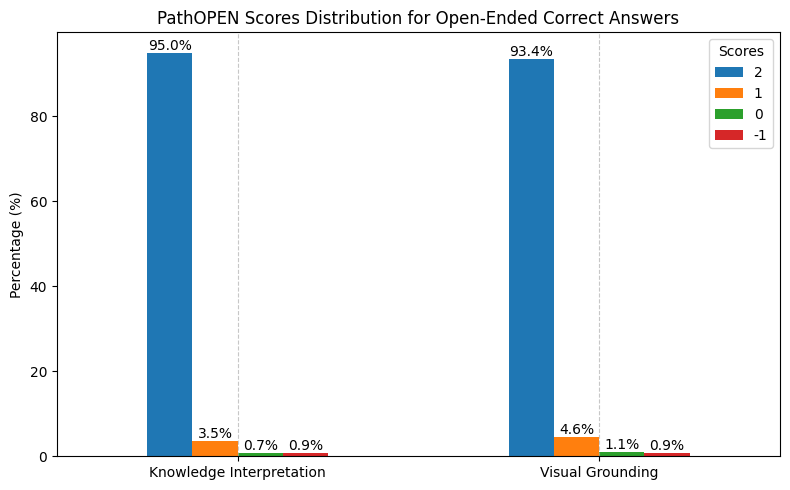

In [26]:
ax = combined_correct_answers_eval_data_open_ended.plot(kind='bar', figsize=(8, 5))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
ax.set_title('PathOPEN Scores Distribution for Open-Ended Correct Answers')
ax.set_ylabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_correct_answers_combined.png')
plt.show()

Open-Ended MCQs

In [29]:
combined_correct_answers_eval_data_mcq = combined_correct_answers_eval_data.loc['MCQ'].copy()

combined_correct_answers_eval_data_mcq['Level 2'] = round((combined_correct_answers_eval_data_mcq['Level 2']/combined_correct_answers_eval_data_mcq['Total'])*100, 2)
combined_correct_answers_eval_data_mcq['Level 1'] = round((combined_correct_answers_eval_data_mcq['Level 1']/combined_correct_answers_eval_data_mcq['Total'])*100, 2)
combined_correct_answers_eval_data_mcq['Level 0'] = round((combined_correct_answers_eval_data_mcq['Level 0']/combined_correct_answers_eval_data_mcq['Total'])*100, 2)
combined_correct_answers_eval_data_mcq['Level -1'] = round((combined_correct_answers_eval_data_mcq['Level -1']/combined_correct_answers_eval_data_mcq['Total'])*100, 2)
combined_correct_answers_eval_data_mcq_total = combined_correct_answers_eval_data_mcq['Total']
combined_correct_answers_eval_data_mcq = combined_correct_answers_eval_data_mcq.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                'Level 1': '1',
                                                                                                                'Level 0': '0',
                                                                                                                'Level -1': '-1'})

combined_correct_answers_eval_data_mcq

,2,1,0,-1
Knowledge Interpretation,96.09,1.30,2.17,0.43
Visual Grounding,92.17,4.78,2.61,0.43


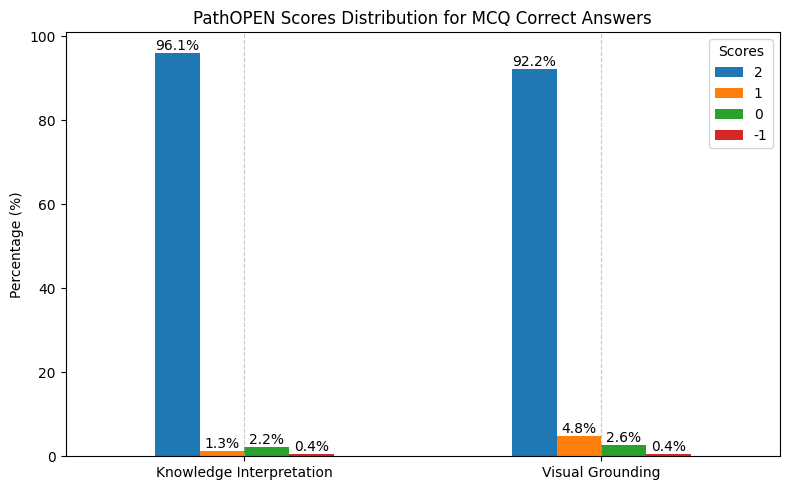

In [31]:
ax = combined_correct_answers_eval_data_mcq.plot(kind='bar', figsize=(8, 5))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
ax.set_title('PathOPEN Scores Distribution for MCQ Correct Answers')
ax.set_ylabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_correct_answers_combined.png')
plt.show()

Close-Ended

In [33]:
combined_correct_answers_eval_data_close_ended = combined_correct_answers_eval_data.loc['Close-Ended'].copy()

combined_correct_answers_eval_data_close_ended['Level 2'] = round((combined_correct_answers_eval_data_close_ended['Level 2']/combined_correct_answers_eval_data_close_ended['Total'])*100, 2)
combined_correct_answers_eval_data_close_ended['Level 1'] = round((combined_correct_answers_eval_data_close_ended['Level 1']/combined_correct_answers_eval_data_close_ended['Total'])*100, 2)
combined_correct_answers_eval_data_close_ended['Level 0'] = round((combined_correct_answers_eval_data_close_ended['Level 0']/combined_correct_answers_eval_data_close_ended['Total'])*100, 2)
combined_correct_answers_eval_data_close_ended['Level -1'] = round((combined_correct_answers_eval_data_close_ended['Level -1']/combined_correct_answers_eval_data_close_ended['Total'])*100, 2)
combined_correct_answers_eval_data_close_ended_total = combined_correct_answers_eval_data_close_ended['Total']
combined_correct_answers_eval_data_close_ended = combined_correct_answers_eval_data_close_ended.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                                        'Level 1': '1',
                                                                                                                                        'Level 0': '0',
                                                                                                                                        'Level -1': '-1'})

combined_correct_answers_eval_data_close_ended

,2,1,0,-1
Visual Grounding,96.96,1.74,1.3,0.0


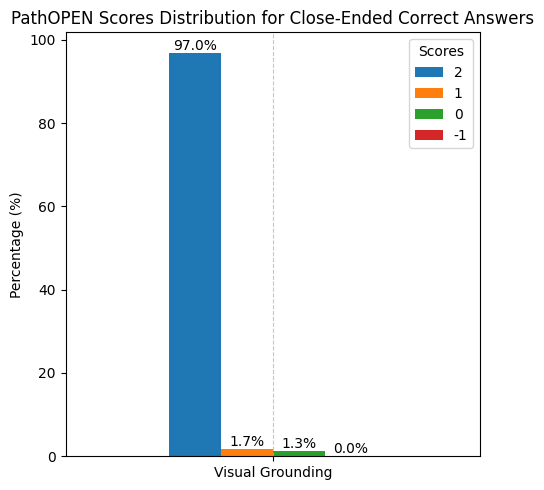

In [35]:
ax = combined_correct_answers_eval_data_close_ended.plot(kind='bar', figsize=(5, 5))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
ax.set_title('PathOPEN Scores Distribution for Close-Ended Correct Answers')
ax.set_ylabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_close_ended_correct_answers_combined.png')
plt.show()

Wrong Answers

In [36]:
combined_wrong_answers_eval_data = wrong_answers_eval_data['evaluator1'] + wrong_answers_eval_data['evaluator2'] + wrong_answers_eval_data['evaluator3'] + wrong_answers_eval_data['evaluator4'] + wrong_answers_eval_data['evaluator5']
combined_wrong_answers_eval_data

Total  Level 2  Level 1  Level 0  Level -1
Open-Ended Error Proximity     348       56      163      123         6
           Visual Grounding    348       60      137      145         6
MCQ        Error Proximity     920      126      276      514         4
           Visual Grounding    920      131      189      595         5

Open-Ended Correct Answers

In [38]:
combined_wrong_answers_eval_data_open_ended = combined_wrong_answers_eval_data.loc['Open-Ended'].copy()

combined_wrong_answers_eval_data_open_ended['Level 2'] = round((combined_wrong_answers_eval_data_open_ended['Level 2']/combined_wrong_answers_eval_data_open_ended['Total'])*100, 2)
combined_wrong_answers_eval_data_open_ended['Level 1'] = round((combined_wrong_answers_eval_data_open_ended['Level 1']/combined_wrong_answers_eval_data_open_ended['Total'])*100, 2)
combined_wrong_answers_eval_data_open_ended['Level 0'] = round((combined_wrong_answers_eval_data_open_ended['Level 0']/combined_wrong_answers_eval_data_open_ended['Total'])*100, 2)
combined_wrong_answers_eval_data_open_ended['Level -1'] = round((combined_wrong_answers_eval_data_open_ended['Level -1']/combined_wrong_answers_eval_data_open_ended['Total'])*100, 2)
combined_wrong_answers_eval_data_open_ended_total = combined_wrong_answers_eval_data_open_ended['Total']
combined_wrong_answers_eval_data_open_ended = combined_wrong_answers_eval_data_open_ended.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                                    'Level 1': '1',
                                                                                                                                    'Level 0': '0',
                                                                                                                                    'Level -1': '-1'})

combined_wrong_answers_eval_data_open_ended

,2,1,0,-1
Error Proximity,16.09,46.84,35.34,1.72
Visual Grounding,17.24,39.37,41.67,1.72


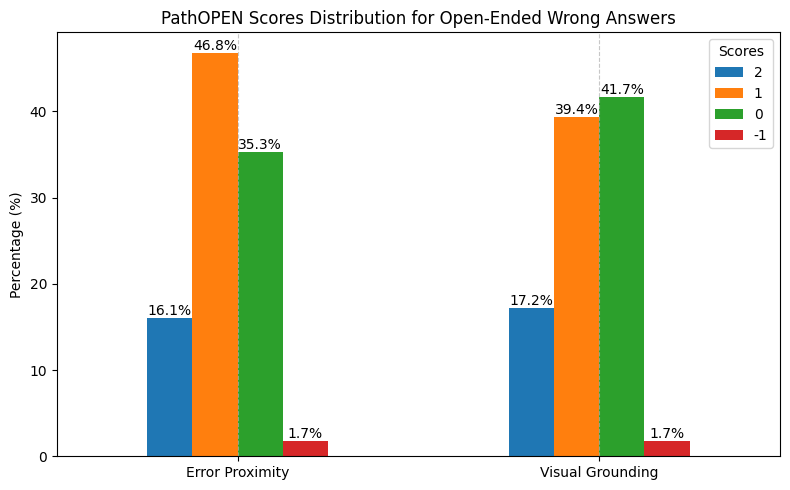

In [39]:
ax = combined_wrong_answers_eval_data_open_ended.plot(kind='bar', figsize=(8, 5))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
ax.set_title('PathOPEN Scores Distribution for Open-Ended Wrong Answers')
ax.set_ylabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_wrong_answers_combined.png')
plt.show()

Open-Ended MCQ

In [40]:
combined_wrong_answers_eval_data_mcq = combined_wrong_answers_eval_data.loc['MCQ'].copy()

combined_wrong_answers_eval_data_mcq['Level 2'] = round((combined_wrong_answers_eval_data_mcq['Level 2']/combined_wrong_answers_eval_data_mcq['Total'])*100, 2)
combined_wrong_answers_eval_data_mcq['Level 1'] = round((combined_wrong_answers_eval_data_mcq['Level 1']/combined_wrong_answers_eval_data_mcq['Total'])*100, 2)
combined_wrong_answers_eval_data_mcq['Level 0'] = round((combined_wrong_answers_eval_data_mcq['Level 0']/combined_wrong_answers_eval_data_mcq['Total'])*100, 2)
combined_wrong_answers_eval_data_mcq['Level -1'] = round((combined_wrong_answers_eval_data_mcq['Level -1']/combined_wrong_answers_eval_data_mcq['Total'])*100, 2)
combined_wrong_answers_eval_data_mcq_total = combined_wrong_answers_eval_data_mcq['Total']
combined_wrong_answers_eval_data_mcq = combined_wrong_answers_eval_data_mcq.drop(columns=['Total']).rename(columns={'Level 2': '2',
                                                                                                                    'Level 1': '1',
                                                                                                                    'Level 0': '0',
                                                                                                                    'Level -1': '-1'})

combined_wrong_answers_eval_data_mcq

,2,1,0,-1
Error Proximity,13.70,30.00,55.87,0.43
Visual Grounding,14.24,20.54,64.67,0.54


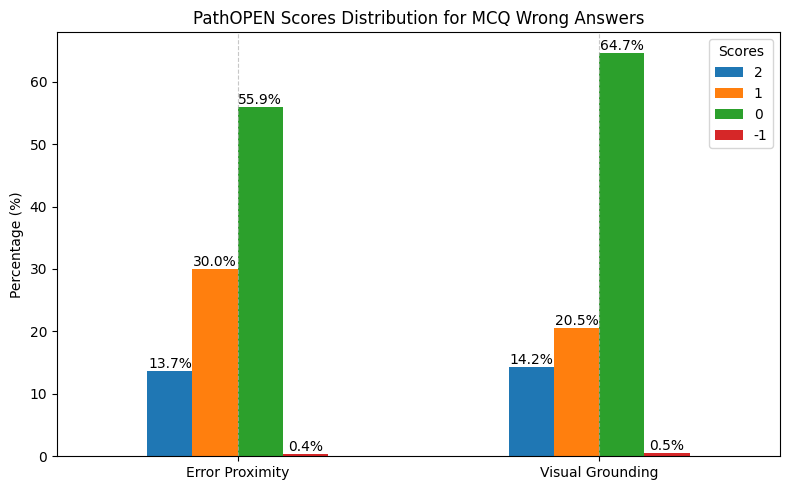

In [41]:
ax = combined_wrong_answers_eval_data_mcq.plot(kind='bar', figsize=(8, 5))
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)
ax.set_title('PathOPEN Scores Distribution for MCQ Wrong Answers')
ax.set_ylabel('Percentage (%)')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.legend(title='Scores', loc='best')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_wrong_answers_combined.png')
plt.show()